## Construção do Modelo

### Importando as Bibliotecas

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

### Importando o dataset

In [11]:
df_ml = pd.read_csv("../data/processed/ml_dataset.csv", sep=";")
df_ml.shape

(1985, 53)

### Definindo as Features, X e y

In [12]:
features = ['ida', 'ieg', 'ips', 'ipp', 'fase', 'ipv']
X = df_ml[features]
y = df_ml['risco_futuro']

### Separação em Treino e Teste (80% treino, 20% teste)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Treino do Modelos

In [14]:

# Modelo 1: Regressão Logística
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Modelo 2: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Avaliação dos Modelos

In [15]:
# Prevendo as probabilidades para a Curva ROC
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Calculando a Área Sob a Curva (AUC - quanto mais perto de 1, melhor)
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

### Comparação entre Modelos

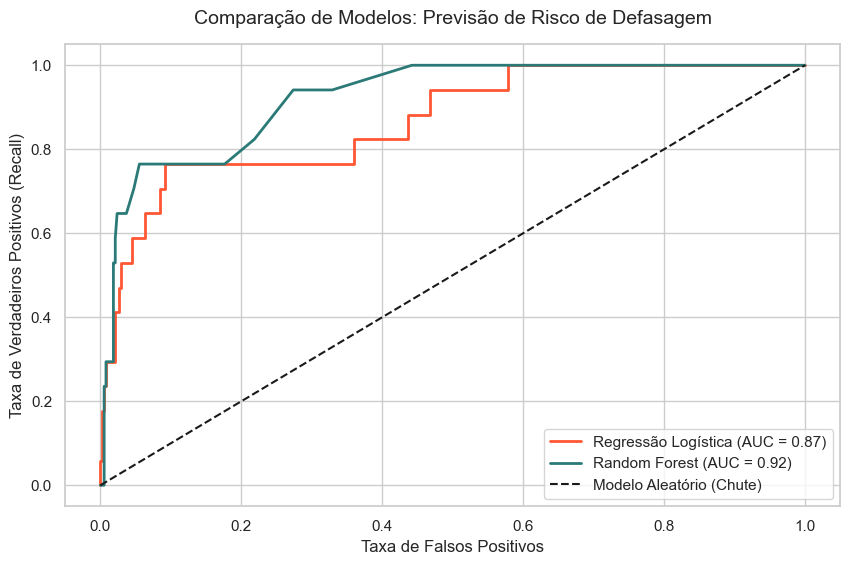

In [16]:
# Gerando os dados para plotar a curva
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)


# --- PLOTANDO A COMPARAÇÃO (CURVA ROC) ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {auc_log:.2f})', color='#FF5733', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='#2B7A78', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório (Chute)')

plt.title('Comparação de Modelos: Previsão de Risco de Defasagem', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.show()

### Relatório Detalhado dos Modelos

In [17]:
print("--- Relatório da Regressão Logística ---")
print(classification_report(y_test, log_reg.predict(X_test)))

print("--- Relatório do Random Forest ---")
print(classification_report(y_test, rf_clf.predict(X_test)))

--- Relatório da Regressão Logística ---
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       380
           1       0.14      0.76      0.23        17

    accuracy                           0.78       397
   macro avg       0.56      0.77      0.55       397
weighted avg       0.95      0.78      0.85       397

--- Relatório do Random Forest ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       380
           1       0.60      0.18      0.27        17

    accuracy                           0.96       397
   macro avg       0.78      0.59      0.63       397
weighted avg       0.95      0.96      0.95       397



### Escolha do Modelo Definitivo

Após refinar nossas features com base na matriz de correlação (removendo a multicolinearidade da variável 'idade' e adicionando o 'ipv'), nossos modelos deram um salto de performance. O Random Forest atingiu um impressionante AUC de 0.92. No entanto, como cientistas de dados focados no impacto social da Passos Mágicos, nós o descartamos.  
Por quê? Porque o seu Recall para alunos em risco foi de apenas 18%. Optamos pela Regressão Logística (AUC 0.87), que entregou um Recall de 76%. Preferimos um modelo que gera alguns alarmes falsos preventivos (Precision de 14%) do que um modelo cego que abandona 8 em cada 10 alunos que precisam de ajuda.

### Criação do Modelo Treinado

In [18]:
import joblib

# Exportando o modelo treinado de Regressão Logística
joblib.dump(
    log_reg,
    "../models/modelo_risco_passos_magicos.pkl"
)

print("Modelo salvo com sucesso na sua máquina!")

Modelo salvo com sucesso na sua máquina!
